<a name="top" id="top"></a>

<div align="center">
    <h1>Quantum Annealing via D-Wave</h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/pedromxavier">Pedro Maciel Xavier</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://colab.research.google.com/github/JuliaQUBO/QUBONotebooks/blob/main/notebooks_jl/4-DWave.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="#installation">
        <img src="https://img.shields.io/badge/⚙️-Installation_Instructions-blue" alt="Installation Instructions"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

<a name="installation" id="installation"></a>

## Colab Instructions

If not in a Colab notebook, continue to the next section.

1. Work on a copy of this notebook: _File_ > _Save a copy in Drive_.
2. Execute the following cell to install Julia, IJulia, the shared notebook project, and the precompiled QUBONotebooks sysimage. This can take a couple of minutes.
3. Reload this page after the installation finishes, then continue with **Activate Environment**.


In [ ]:
%%shell

bash <(curl -s "https://raw.githubusercontent.com/JuliaQUBO/QUBONotebooks/main/scripts/install-colab-julia.sh")

### Activate Environment

In [2]:
import Pkg; Pkg.activate(@__DIR__) # Here we go!

  Activating project at `~/repos/QUBONotebooks/notebooks_jl`


## About this Notebook

This notebook will give the first interaction with D-Wave's Quantum Annealer.
It will use the QUBO modeling problem introduced earlier and will define it using **[JuMP](https://jump.dev)**, and then solve them using neal's implementation of simulated annealing classically and D-Wave system package to use Quantum Annealing.
It also uses **[DWave.jl](https://github.com/JuliaQUBO/DWave.jl)** topology and embedding plot helpers to inspect the selected QPU and returned minor embedding.

## Problem statement

We define a QUBO as the following optimization problem:

$$
\min_{x \in \{0,1 \}^n} \sum_{(ij) \in E(G)} Q_{ij}x_i x_j + \sum_{i \in V(G)}Q_{ii}x_i + \beta = \min_{x \in \{0,1 \}^n}  \mathbf{x}' \mathbf{Q} \mathbf{x} + \beta
$$

where we optimize over binary variables $x \in \{ 0,1 \}^n$, on a constrained graph $G(V,E)$ defined by a weighted adjacency matrix $\mathbf{Q}$.
We also include an arbitrary offset  $\beta$.

### Example

Suppose we want to solve the following problem via QUBO

$$
\begin{array}{rl}
\displaystyle%
\min_{\mathbf{x}} & 2x_0+4x_1+4x_2+4x_3+4x_4+4x_5+5x_6+4x_7+5x_8+6x_9+5x_{10} \\
\textrm{s.t.}     & \begin{bmatrix}
1 & 0 & 0 & 1 & 1 & 1 & 0 & 1 & 1 & 1 & 1\\
0 & 1 & 0 & 1 & 0 & 1 & 1 & 0 & 1 & 1 & 1\\
0 & 0 & 1 & 0 & 1 & 0 & 1 & 1 & 1 & 1 & 1
\end{bmatrix}\mathbf{x}=
\begin{bmatrix}
1\\
1\\
1
\end{bmatrix} \\
~ & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

First we would write this problem as a an unconstrained one by penalizing the linear constraints as quadratics in the objective.
Let's first define the problem parameters.

In [3]:
A = [
    1 0 0 1 1 1 0 1 1 1 1
    0 1 0 1 0 1 1 0 1 1 1
    0 0 1 0 1 0 1 1 1 1 1
]
b = [1, 1, 1]
c = [2, 4, 4, 4, 4, 4, 5, 4, 5, 6, 5];

In order to define the $\mathbf{Q}$ matrix, we first write the problem

$$
\begin{array}{rl}
    \displaystyle%
    \min_{\mathbf{x}} &\mathbf{c}' \mathbf{x} \\
    \textrm{s.t.}     & \mathbf{A}\mathbf{x} = \mathbf{b} \\
    ~                 & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

as follows:

$$
\begin{array}{rl}
    \displaystyle%
    \min_{\mathbf{x}} & \mathbf{c}' \mathbf{x} + \rho (\mathbf{A}\mathbf{x}-\mathbf{b})' (\mathbf{A}\mathbf{x}-\mathbf{b}) \\
    \textrm{s.t.}     & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

Exploiting the fact that $x^2=x$ for $x \in \{0,1\}$, we can make the linear terms appear in the diagonal of the $\mathbf{Q}$ matrix.

$$
\rho(\mathbf{A}\mathbf{x}-\mathbf{b})'(\mathbf{A}\mathbf{x}-\mathbf{b}) = \rho( \mathbf{x}'(\mathbf{A}'\mathbf{A}) \mathbf{x} - 2(\mathbf{A}'\mathbf{b}) \mathbf{x} + \mathbf{b}'\mathbf{b} )
$$

For this problem in particular, one can prove that a reasonable penalization factor is given by $\rho = \sum_{i=1}^n |c_i| + \epsilon$ with $\epsilon > 0$.

In [4]:
using LinearAlgebra

In [5]:
ϵ = 1
ρ = sum(abs, c) + ϵ
Q = diagm(c) + ρ * (A'A - 2 * diagm(A'b))
β = ρ * b'b

display(Q)
println(β)

11×11 Matrix{Int64}:
 -46    0    0   48   48   48    0   48    48    48    48
   0  -44    0   48    0   48   48    0    48    48    48
   0    0  -44    0   48    0   48   48    48    48    48
  48   48    0  -92   48   96   48   48    96    96    96
  48    0   48   48  -92   48   48   96    96    96    96
  48   48    0   96   48  -92   48   48    96    96    96
   0   48   48   48   48   48  -91   48    96    96    96
  48    0   48   48   96   48   48  -92    96    96    96
  48   48   48   96   96   96   96   96  -139   144   144
  48   48   48   96   96   96   96   96   144  -138   144
  48   48   48   96   96   96   96   96   144   144  -139

144


We can visualize the graph that defines this instance using the Q matrix as the adjacency matrix of a graph.

In [6]:
using DWave
DWave.PythonCall.pyimport("matplotlib") # Load conda Matplotlib before Plots/GR shared libraries.
using Plots
using JuMP
using QUBO

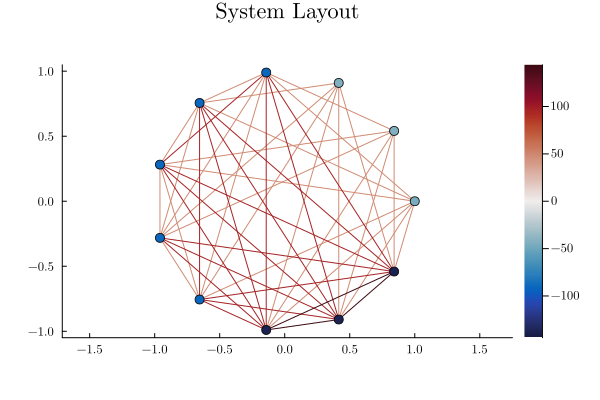

In [7]:
plot(QUBOTools.SystemLayoutPlot(Q))

Let's define a QUBO model and then solve it via simulated annealing.

In [8]:
using JuMP
using QUBO
using DWave

In [9]:
# Define empty model
qubo_model = Model()

# Define the variables
@variable(qubo_model, x[1:11], Bin)

# Define the objective function
@objective(qubo_model, Min, x' * Q * x + β)

# Print the model
print(qubo_model)

In [10]:
# Use D-Wave's simulated annealer 'Neal'
set_optimizer(qubo_model, DWave.Neal.Optimizer)

set_optimizer_attribute(qubo_model, "num_reads", 1_000)

optimize!(qubo_model)

println("Minimum energy: $(objective_value(qubo_model))")

Minimum energy: 5.0


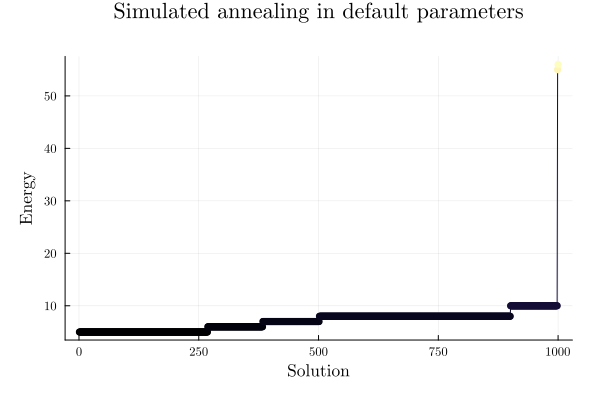

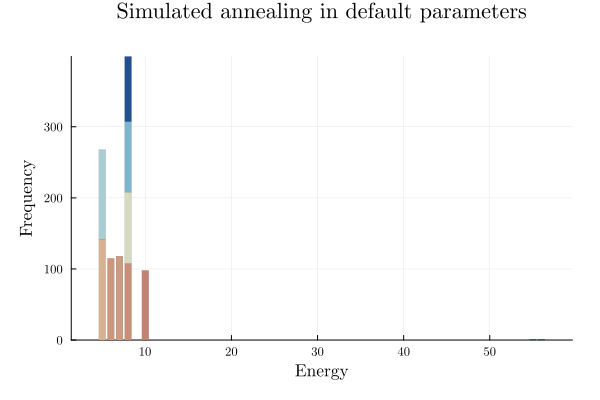

In [11]:
neal_solution = QUBOTools.solution(QUBOTools.backend(qubo_model))

display(plot(QUBOTools.EnergyDistributionPlot(neal_solution); title="Simulated annealing in default parameters"))
plot(QUBOTools.EnergyFrequencyPlot(neal_solution); title="Simulated annealing in default parameters")

Notice that this is the same example we have been solving earlier (via Integer Programming in the Quiz 2, via Ising model and QUBO in Notebook 2).

## Now let's solve this using Quantum Annealing!

Before running the D-Wave QPU cells, create a free D-Wave Leap account at https://cloud.dwavesys.com/leap/ and copy your API token from the Leap dashboard.

In Colab, use _Runtime_ > _Secrets_ to add a secret named `DWAVE_API_TOKEN`. For a local Julia notebook, set the same environment variable before starting Jupyter:

```julia
api_token = get(ENV, "DWAVE_API_TOKEN", "")
@assert !isempty(api_token) "Set the DWAVE_API_TOKEN environment variable before running this cell"
```

If `DWAVE_API_TOKEN` is missing or no D-Wave QPU is available, the cells below print a clear message and fall back to `DWave.Neal.Optimizer`, the local simulated-annealing backend used earlier in this notebook.


In [12]:
api_token = get(ENV, "DWAVE_API_TOKEN", "")
if isempty(api_token)
    println("DWAVE_API_TOKEN is not set. Create a free D-Wave Leap account at https://cloud.dwavesys.com/leap/, copy your token from the Leap dashboard, then add DWAVE_API_TOKEN to Colab Secrets or your local environment. The QPU cells below will use DWave.Neal.Optimizer (SimulatedAnnealingSampler) fallback.")
end


In [13]:
# Use D-Wave's quantum annealer when available, otherwise use simulated annealing.
sampler = nothing
qpu_available = false

try
    if isempty(api_token)
        error("DWAVE_API_TOKEN is not set")
    end

    sampler = DWave.dwave_system.DWaveSampler(
        token=api_token,
        solver=Dict("qpu" => true),
    )
    embedding_sampler = DWave.dwave_system.EmbeddingComposite(sampler)

    set_optimizer(qubo_model, DWave.Optimizer)

    set_optimizer_attribute(qubo_model, "sampler", embedding_sampler)
    set_optimizer_attribute(qubo_model, "num_reads", 1024)
    set_optimizer_attribute(qubo_model, "return_embedding", true)

    optimize!(qubo_model)
    qpu_available = true

    println("Minimum energy: $(objective_value(qubo_model))")
catch err
    println("D-Wave QPU is unavailable or DWAVE_API_TOKEN is missing. Falling back to DWave.Neal.Optimizer (SimulatedAnnealingSampler).")
    println("Reason: $(sprint(showerror, err))")

    set_optimizer(qubo_model, DWave.Neal.Optimizer)
    set_optimizer_attribute(qubo_model, "num_reads", 1_000)

    optimize!(qubo_model)

    println("Fallback minimum energy: $(objective_value(qubo_model))")
end


Minimum energy: 5.0


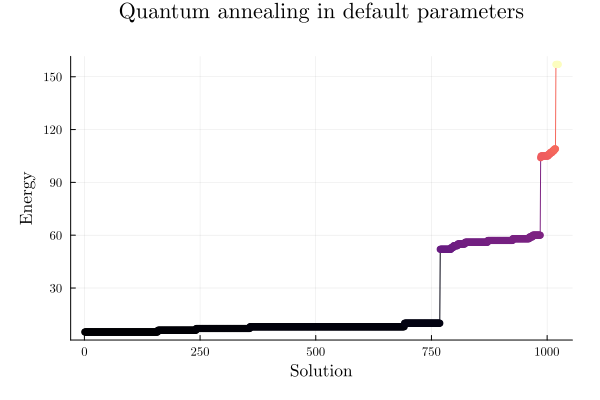

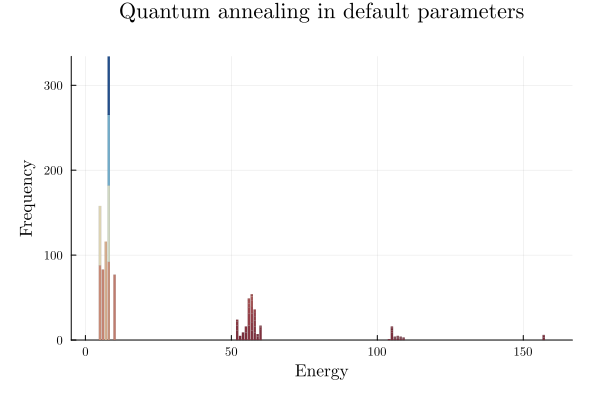

In [14]:
qpu_solution = QUBOTools.solution(QUBOTools.backend(qubo_model))
plot_title = qpu_available ? "Quantum annealing in default parameters" : "Simulated annealing fallback for unavailable D-Wave QPU"

display(plot(QUBOTools.EnergyDistributionPlot(qpu_solution); title=plot_title))
plot(QUBOTools.EnergyFrequencyPlot(qpu_solution); title=plot_title)


In [15]:
# DWave.jl plotting helpers wrap D-Wave NetworkX and return notebook-displayable Matplotlib figures.

In [16]:
# Reuse the QPU selected for the quantum annealing solve above when one is available.
if qpu_available
    sampler
else
    println("No D-Wave QPU sampler is available while using simulated annealing fallback.")
end


Python: <dwave.system.samplers.dwave_sampler.DWaveSampler object at 0x71b3baf41940>

Solver id:     Advantage_system4
Topology:      pegasus, shape=[16]
Working graph: 5627 qubits, 40279 couplers


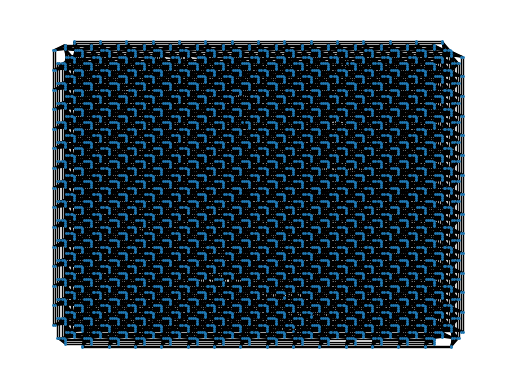

In [17]:
function draw_topology(sampler)
    arch = DWave.WorkingGraph(sampler)
    topology = isnothing(arch.topology_type) ? "unknown" : arch.topology_type

    println("Solver id:     $(get(arch.metadata, "solver_name", "unknown"))")
    println("Topology:      $(topology), shape=$(arch.topology_shape)")
    println("Working graph: $(length(arch.nodes)) qubits, $(length(arch.edges)) couplers")

    return DWave.draw_topology(arch; node_size=1, with_labels=false)
end

if qpu_available
    draw_topology(sampler)
else
    println("Skipping D-Wave QPU topology plot while using simulated annealing fallback.")
end


In [18]:
sol = QUBOTools.solution(QUBOTools.backend(qubo_model))

QUBOTools.SampleSet{Float64, Int64} with 70 samples:
  QUBOTools.Sample{Float64, Int64}([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], 5.0, 88)
  QUBOTools.Sample{Float64, Int64}([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], 5.0, 70)
  QUBOTools.Sample{Float64, Int64}([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0], 6.0, 83)
  QUBOTools.Sample{Float64, Int64}([1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], 7.0, 116)
  QUBOTools.Sample{Float64, Int64}([0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0], 8.0, 92)
  QUBOTools.Sample{Float64, Int64}([0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0], 8.0, 90)
  QUBOTools.Sample{Float64, Int64}([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0], 8.0, 83)
  QUBOTools.Sample{Float64, Int64}([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0], 8.0, 69)
  QUBOTools.Sample{Float64, Int64}([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], 10.0, 77)
  ⋮


In [19]:
data = QUBOTools.metadata(sol)
info = get(data, "dwave_info", nothing)

Dict{String, Any} with 4 entries:
  "timing"            => Dict{String, Any}("qpu_delay_time_per_sample"=>20.58, …
  "chip_info"         => Dict{String, Any}("chip_id"=>"Advantage_system4", "top…
  "embedding_context" => Dict{String, Any}("timing"=>Dict{String, Any}("embeddi…
  "problem_id"        => "f1cee9d7-3dd6-43d6-a1c1-e9d37be7c7c3"

Embedding:     11 variables, 19 qubits on 5627-qubit working graph


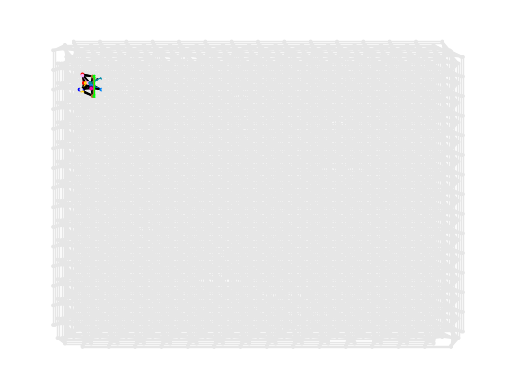

In [20]:
function draw_embedding(sampleset)
    embedding = DWave.embedding(sampleset)
    embedding === nothing && error("No embedding was returned. Set return_embedding=true before optimize!()")

    arch = DWave.WorkingGraph(QUBOTools.metadata(sampleset))
    embedded_qubits = unique([qubit for chain in values(embedding) for qubit in chain])

    println("Embedding:     $(length(embedding)) variables, $(length(embedded_qubits)) qubits on $(length(arch.nodes))-qubit working graph")

    return DWave.draw_embedding(sampleset; node_size=2)
end

if qpu_available
    draw_embedding(sol)
else
    println("Skipping D-Wave QPU embedding plot while using simulated annealing fallback.")
end


Now we can play with the other parameters such as Annealing time, chain strenght, and annealing schedule to improve the performance of D-Wave's Quantum Annealing.

# References

- [Julia Colab Notebook Template](https://colab.research.google.com/github/ageron/julia_notebooks/blob/master/Julia_Colab_Notebook_Template.ipynb)
- [QuIPML22](https://github.com/bernalde/QuIPML22/)

## Validate Installation

In [21]:
versioninfo()

## Local Installation Instructions

If you don't have a Julia installation yet, consider using [juliaup](https://github.com/JuliaLang/juliaup).
Otherwise, run the next cell to install the necessary packages.

### Install Julia Packages

In [22]:
import Pkg

Pkg.activate(@__DIR__)
Pkg.instantiate(; io = devnull) # Suppress Output

  Activating project at `~/repos/QUBONotebooks/notebooks_jl`


<div align="center">
    <a href="#top">🔝 Go back to the top 🔝</a>
</div>